# Behind the Curve 🐢
### When the Fed is too easy, do stocks really get a tailwind?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Every few years the phrase comes back: *the Fed is behind the curve*. Rates are too low for the
inflation in front of it, money is too easy, and — the story goes — that is good for stocks and
bad for bonds, until the Fed catches up. A famous formula, the **Taylor rule**, even says where
rates "should" be. We built that formula the way an investor at the time could have, and asked
forty years of data whether the gap between the Fed and the rule ever told you anything.

> 📓 **This is the plain-language layer.** The regressions, the bias corrections and the
> simulation null are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is drawn by the code beside it, on the real
> tape (final-vintage US macro, 1969–2009).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 80
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from taylorgap import data, strategy as st

## Beat 0 · The verdict, read first (real tape)

| Axis | Stamp |
|---|---|
| **Signal** — does the Taylor gap forecast stocks or bonds? | **None** |
| **Tradability** — does a "buy when the Fed is behind" rule pay? | **Mirage** |

> **In one sentence:** Being behind the curve bought stocks no tailwind — the real-time Taylor gap's one-quarter equity slope is +0.14% per point (simulation p = 0.69), only the bond headwind comes close (p = 0.06), and the timing rule's net Sharpe was 0.12 against 0.28 for buy-and-hold, on final-vintage data that flatter it.

*Numbers sourced to [`docs/results.md`](../docs/results.md) (as-of 2009-12-31, fingerprint
`09aa8b5c4d4e`).*

## 1 · The claim

John Taylor's 1993 paper wrote down a simple recipe for the Fed's interest rate: start at
2% real, add inflation, then lean against it — half a point higher for every point inflation is
above 2%, half a point higher for every point the economy runs above its potential.

> **policy rate the rule wants = 2 + inflation + ½ × (inflation − 2) + ½ × output gap**

When the actual rate sits *below* that, the Fed is "behind the curve": too easy. The believers'
version, at full strength: easy money lifts stocks (cheap financing, a hunt for yield) and hurts
long bonds (inflation risk), and a Fed that is *ahead* — too tight — is the time to sell stocks.

## 2 · So what?

If true, it would be a gift: one number, computed from public data four times a year, that tells
you when to own stocks. It would also say something about markets — that investors systematically
fail to price the Fed's own stance, which is the most-watched number in finance.

## 3 · How we'd know

Written down **before** we looked:

- Build the rule only from what an investor could have known: inflation and the economy **one
  quarter late** (that's when the numbers come out), and an output gap estimated from **past data
  only** — two ways, from GDP and from unemployment.
- Ask whether the gap forecasts the **next quarter's** stock return (over cash) and the change in
  long-bond yields, with error bars built for a slow-moving signal.
- Trade it: stocks when the Fed is behind, cash otherwise, one quarter later, after costs — and
  race it against simply holding stocks.

**What would make us say "mirage":** no forecast stronger than chance, and a timing rule that
doesn't beat buy-and-hold.

## 4 · The teardown

### 4.1 The Fed vs the rule

real tape: signals 1969-03-31 -> 2009-09-30, 163 quarters | as-of 2009-12-31
macro: statsmodels macrodata, FINAL VINTAGE | equity: Fama-French TOTAL return | bond: Moody's AAA yield


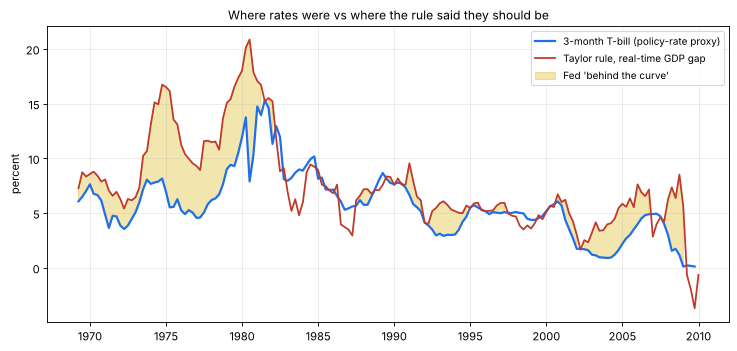

share of quarters 'behind the curve': 73%


In [2]:
p = st.real_panel()
print(f"real tape: signals {p.index[0].date()} -> {p['tgap_hp'].dropna().index[-1].date()}, "
      f"{int(p['tgap_hp'].notna().sum())} quarters | as-of {data.AS_OF}")
print("macro: statsmodels macrodata, FINAL VINTAGE | equity: Fama-French TOTAL return | "
      "bond: Moody's AAA yield")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(p.index, p["i"], color="#1f6feb", lw=2, label="3-month T-bill (policy-rate proxy)")
ax.plot(p.index, p["istar_hp"], color="#c0392b", lw=1.6, label="Taylor rule, real-time GDP gap")
ax.fill_between(p.index, p["i"], p["istar_hp"], where=p["tgap_hp"] < 0, color="#dab617",
                alpha=0.35, label="Fed 'behind the curve'")
ax.set_ylabel("percent"); ax.legend(fontsize=9, loc="upper right")
ax.set_title("Where rates were vs where the rule said they should be", fontsize=11)
plt.show()
print(f"share of quarters 'behind the curve': {(p['tgap_hp'] < 0).mean():.0%}")

The yellow is the Fed being "too easy" by this yardstick — 73% of quarters. Most
of that is the 1970s (a famously late Fed) and the low-rate 2000s. Part of it is the yardstick:
the T-bill sits a little below the Fed's own rate.

> 🔬 **For the quants.** The level offset does not move any regression slope; §6 of the
> quant notebook adds a real-time-demeaned version of the trading rule for exactly this reason.

### 4.2 The gap you could know vs the gap a historian sees

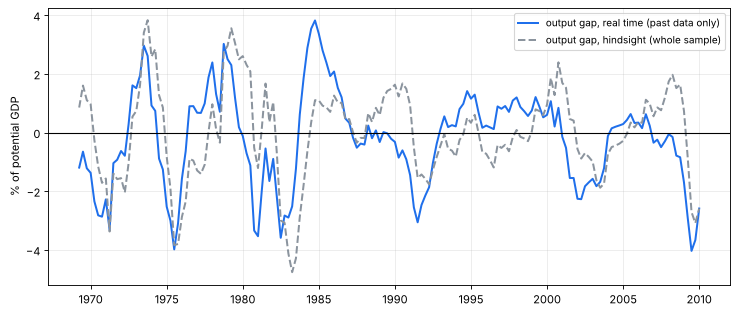

correlation real-time vs hindsight: 0.55; average disagreement: 1.28 points


In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(p.index, p["gap_hp"], color="#1f6feb", lw=1.8, label="output gap, real time (past data only)")
ax.plot(p.index, p["gap_hind"], color="#8b949e", lw=1.8, ls="--",
        label="output gap, hindsight (whole sample)")
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("% of potential GDP"); ax.legend(fontsize=9)
plt.show()
ag = st.gap_agreement(p)
print(f"correlation real-time vs hindsight: {ag['corr_gap_hp_hind']:.2f}; "
      f"average disagreement: {ag['mean_abs_gap_rev']:.2f} points")

The same economy, two answers. Even on numbers that have since been revised and polished, the
real-time estimate correlates only 0.55 with the one computed in hindsight.
Athanasios Orphanides (2001) made this point about the Fed itself: the gaps policymakers
actually saw were often badly wrong, so judging the Fed — or trading on it — with today's
data flatters everybody. **Our data are the revised kind, so everything below is the best case.**

### 4.3 Does the gap forecast next quarter's stock return?

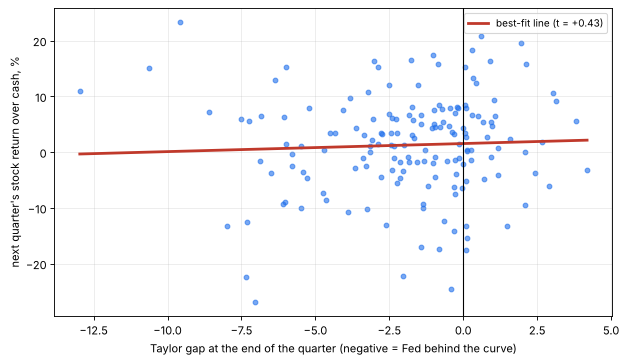

In [4]:
x = p["tgap_hp"]; y = p["eq_xs"].shift(-1)
ok = x.notna() & y.notna()
r = st.predictive_regression(p, "tgap_hp", "eq_xs", 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x[ok], y[ok] * 100, s=18, color="#1f6feb", alpha=0.6)
xx = np.linspace(x[ok].min(), x[ok].max(), 50)
ax.plot(xx, (y[ok].mean() + r["slope"] * (xx - x[ok].mean())) * 100, color="#c0392b", lw=2.5,
        label=f"best-fit line (t = {r['t']:+.2f})")
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("Taylor gap at the end of the quarter (negative = Fed behind the curve)")
ax.set_ylabel("next quarter's stock return over cash, %"); ax.legend(fontsize=9)
plt.show()

If the claim were right, the cloud would tilt down to the right: behind the curve (left) should
be followed by good quarters. It doesn't tilt at all — if anything the line leans the other way
(slope +0.14% per point, a *t* of +0.43, which is noise).

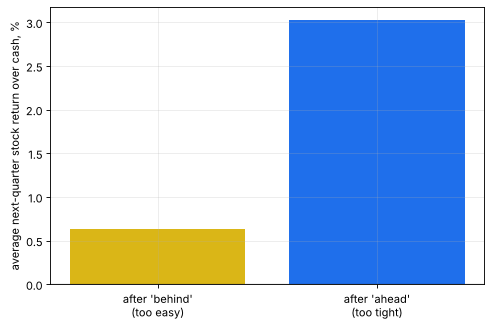

behind: +0.64% over 119 quarters; ahead: +3.02% over 44 quarters (t of the difference -1.39)


In [5]:
cm = st.conditional_means(p, "tgap_hp", "eq_xs")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(["after 'behind'\n(too easy)", "after 'ahead'\n(too tight)"],
       [cm["mean_behind"] * 100, cm["mean_ahead"] * 100], color=["#dab617", "#1f6feb"])
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("average next-quarter stock return over cash, %")
plt.show()
print(f"behind: {cm['mean_behind']:+.2%} over {cm['n_behind']} quarters; "
      f"ahead: {cm['mean_ahead']:+.2%} over {cm['n_ahead']} quarters "
      f"(t of the difference {cm['t_diff']:+.2f})")

Backwards, in fact: quarters after a "too tight" Fed did better (+3.02%) than
quarters after a "too easy" one (+0.64%) — not significantly, but certainly not the
claim.

### 4.4 The bond side — closer, still not there

In [6]:
rb = st.predictive_regression(p, "tgap_hp", "d_aaa", 1)
print(f"next-quarter change in the AAA bond yield per point of Taylor gap: {rb['slope']:+.3f} "
      f"percentage points (t = {rb['t']:+.2f})")
rg = st.regime_split(p, "tgap_hp", "d_aaa")
print(f"  before 1987Q3: {rg['slope_pre']:+.3f} (t {rg['t_pre']:+.2f})   "
      f"after: {rg['slope_post']:+.3f} (t {rg['t_post']:+.2f})")

next-quarter change in the AAA bond yield per point of Taylor gap: -0.037 percentage points (t = -2.04)
  before 1987Q3: -0.047 (t -1.85)   after: +0.004 (t +0.28)


Here the sign is the claimed one — a looser Fed was followed by slightly rising yields — with a
*t* of -2.04. But the gap is so slow-moving that ordinary error bars are too generous;
against a simulation built for this exact situation the chance of seeing this by luck is about
0.06 — not below the 5% bar we set. And the effect lives almost entirely in the
1970s–80s inflation era (*t* -1.85 before 1987, +0.28 after).

> 🔬 **For the quants.** The bond leg's two-sided simulation-null p is 0.06
> (one-sided 0.04); the pre-registered bar was two-sided 5%. The Stambaugh
> correction moves its *t* toward zero.

## 5 · The verdict

**Signal: None.** The equity leg — the heart of the claim — is noise with the wrong
sign under both output gaps and at 1, 4 and 8 quarters. The bond leg points the claimed way but
does not clear a test built for a persistent signal, and it is a story about one era.

**Tradability: Mirage.** See below.

## 6 · Could you trade it?

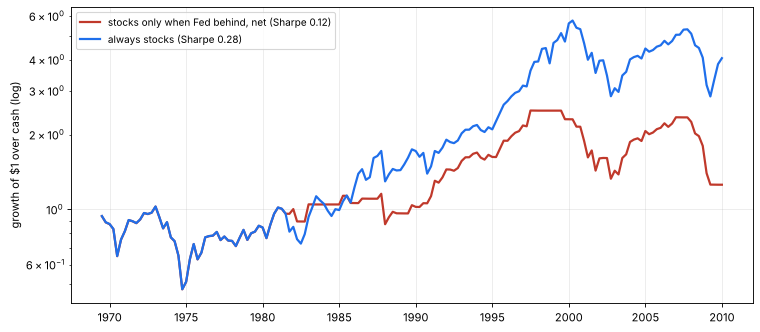

invested 73% of quarters, 0.88 switches a year
return over cash: rule 1.77%/yr vs buy-and-hold 5.12%/yr


In [7]:
bt = st.timing_backtest(p, "tgap_hp", cost_bp=10)
s = st.backtest_summary(bt)
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(bt.index, (1 + bt["strat_xs_net"]).cumprod(), color="#c0392b", lw=2,
        label=f"stocks only when Fed behind, net (Sharpe {s['sr_net']:.2f})")
ax.plot(bt.index, (1 + bt["bh_xs"]).cumprod(), color="#1f6feb", lw=2,
        label=f"always stocks (Sharpe {s['sr_bh']:.2f})")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 over cash (log)"); ax.legend(fontsize=9)
plt.show()
print(f"invested {s['share_invested']:.0%} of quarters, {s['switches_per_year']:.2f} switches a year")
print(f"return over cash: rule {s['ann_xs_net']:.2%}/yr vs buy-and-hold {s['ann_xs_bh']:.2%}/yr")

The rule earned 1.77% a year over cash against 5.12% for simply holding stocks,
with a lower Sharpe ratio (0.12 vs 0.28). It hardly trades, so costs are not the
problem — sitting in cash during the wrong quarters is. A mirage, and the data are the
flattering, revised kind.

## 7 · Going further 🚪

- **Real-time vintages.** The decisive upgrade is the Philadelphia Fed's real-time data set
  (Croushore and Stark): rebuild the gap with what was printed *then*. On our evidence it can only
  get worse for the claim, but the bond leg deserves the test.
- **Fed funds instead of T-bills,** and the Fed's own preferred inflation measure.
- **The 1970s vs everything since.** The bond effect looks like a Great-Inflation phenomenon. A
  study pre-registering that split on fresh data (other countries' central banks) would settle it.
- **Fork it:** `taylorgap/strategy.py` takes any gap series; swap in your favourite rule.